# Credit Risk and Default Prediction Model
Author: Monya Cisternas

## Introduction

This project develops a machine learning model to classify borrowers into credit risk categories based on financial and behavioral characteristics. The objective is to identify the key drivers of credit risk and build a predictive model capable to accurately segmenting borrowers by their likelihood of default.

## Data Pipeline

The workflow for this project follows a typical end-to-end data science pipeline:

1. Dataset acquisition from Kaggle.
2. Data ingestion into a PostgreSQL database.
3. Data Transformation and structuring using SQL.
4. Data extraction into Python for analysis.
5. Exploratory data analysis and feature investigation.
6. Machine Learning model development for credit risk classification.
7. Deployment of the trained model within an interactive Streamlit dashboard.



## Key Findings

Exploratory data analysis and model results highlight several key factors associated with elevated borrower risk within the dataset:

- Payment history is a strong indicator of borrower risk.
- Younger borrowers appear more frequently in higher risk segments.
- Credit utilization and debt ratios exhibit significant dispersion across borrowers.
- Expected losses are concentrated among higher risk borrowers.

These insights support the development of predictive models capable of identifying borrowers who may present higher credit risk.

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import joblib

## Dataset Overview

The dataset contains borrower financial and credit behavior variables commonly used in credit risk modeling.

These variables capture borrower income, credit exposure, debt levels, and repayment behavior, which are key indicators.

The dataset contains information on 150,000 borrowers across multiple credit risk segments.

In [43]:
df = pd.read_csv("credit_risk_dashboard.csv")

df.head()

,PD,EAD,LGD,expected_loss,risk_segment,age,monthly_income,debt_ratio,revolving_utilization,total_late_payments,open_credit_lines,real_estate_loans
0,0.172379,6987.074674,0.75,903.318454,Very High Risk,45,9120.0,0.802982,0.766127,2,13,6
1,0.060160,2488.592649,0.75,112.285974,High Risk,40,2600.0,0.121876,0.957151,0,4,0
2,0.163395,2002.183986,0.75,245.359700,Very High Risk,38,3042.0,0.085113,0.658180,2,2,0
3,0.075129,771.572261,0.75,43.475807,Very High Risk,30,3300.0,0.036050,0.233810,0,5,0
4,0.016194,57689.538967,0.75,700.656588,Very Low Risk,49,63588.0,0.024926,0.907239,1,7,1


In [44]:
df.shape

(150000, 12)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   PD                     150000 non-null  float64
 1   EAD                    150000 non-null  float64
 2   LGD                    150000 non-null  float64
 3   expected_loss          150000 non-null  float64
 4   risk_segment           150000 non-null  object 
 5   age                    150000 non-null  int64  
 6   monthly_income         150000 non-null  float64
 7   debt_ratio             150000 non-null  float64
 8   revolving_utilization  150000 non-null  float64
 9   total_late_payments    150000 non-null  int64  
 10  open_credit_lines      150000 non-null  int64  
 11  real_estate_loans      150000 non-null  int64  
dtypes: float64(7), int64(4), object(1)
memory usage: 13.7+ MB


The dataset contains a mix of numerical and categorical variables.

Most financial variables such as income, debt ratio, and credit utilization are stored as numeric values, while the borrower risk classification is stored as a categorical variable.

### Risk Segment Distribution 

The dataset contains five borrower risk categories ranging from Very Low Risk to Very High Risk.

The distribution is balanced across all categories, with each risk segment containing approximately 30,000 observations resulting in a balanced dataset.

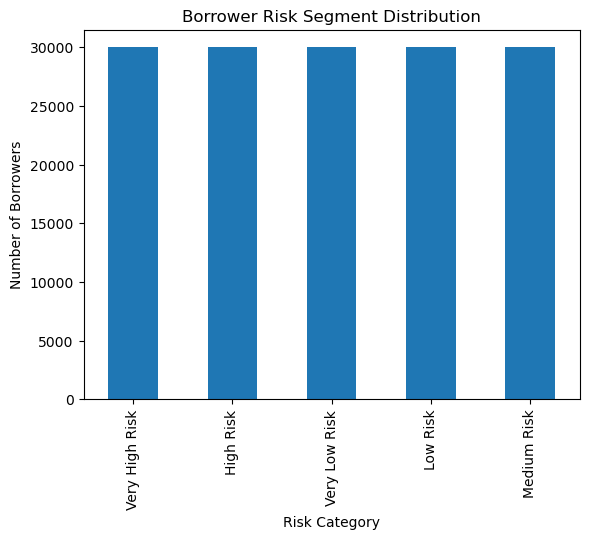

In [46]:
order = ["Very Low Risk", "Low Risk", "Medium Risk", "High Risk", "Very High Risk"]

df["risk_segment"].value_counts().plot(kind = "bar")
plt.title("Borrower Risk Segment Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Borrowers")
plt.show()

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to investigate relationships between borrower characteristics and credit risk segments.

Understanding these relationships helps identify the most important factors influencing borrower default risk and supports the development of predictive models.

## Feature Analysis

### Debt Ratio vs Risk Segment

The debt ratio distribution shows a large number of extreme outliers, with some borrowers exhibiting unusually high debt levels relative to their income.

Despite these outliers, the majority of borrowers across all risk segments maintain relatively low debt ratios. Higher variability appears within the higher risk segments, suggesting that borrowers with excessive debt burdens may be more likely to fall into elevated risk categories

Debt ratio is an important indicator of financial leverage. Borrowers with higher debt obligations relative to income may face greater difficulty servicing their liabilities during periods of financial stress, increasing their probability of default.

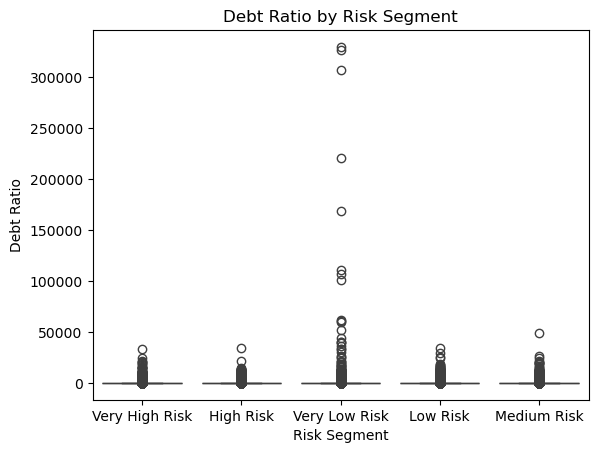

In [47]:
sns.boxplot(x = "risk_segment", y = "debt_ratio", data = df)

plt.title("Debt Ratio by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Debt Ratio")

plt.show()

### Late Payments vs Risk Segment 

The distribution of late payments varies significantly across risk segments. Borrowers classified in the Very High Risk category exhibit noticeably higher numbers of late payment events compared to other segments.



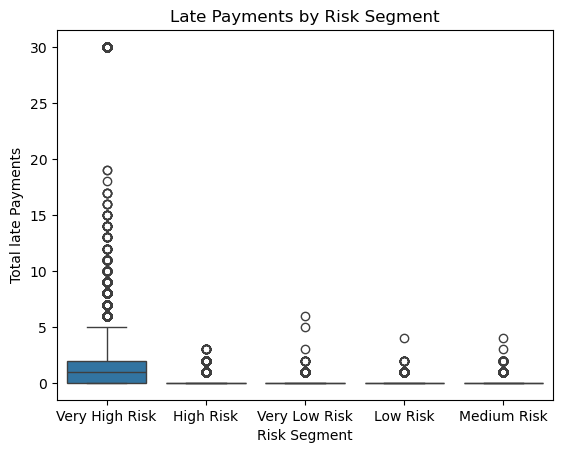

In [48]:
sns.boxplot(x = "risk_segment", y = "total_late_payments", data = df)

plt.title("Late Payments by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Total late Payments")

plt.show()

### Credit Utilization vs Risk Segment

Credit utilization measures the proportion of available revolving credit currently being used by a borrower.

The distribution shows a large concentration of borrowers with relatively low utilization levels, alongside a number of extreme outliers with very high utilization values.

High credit utilization can indicate financial stress, as borrowers may be relying heavily on available credit to meet financial obligations. Although the majority of borrowers maintain moderate utilization levels, elevated utilization levels may signal increased credit risk.

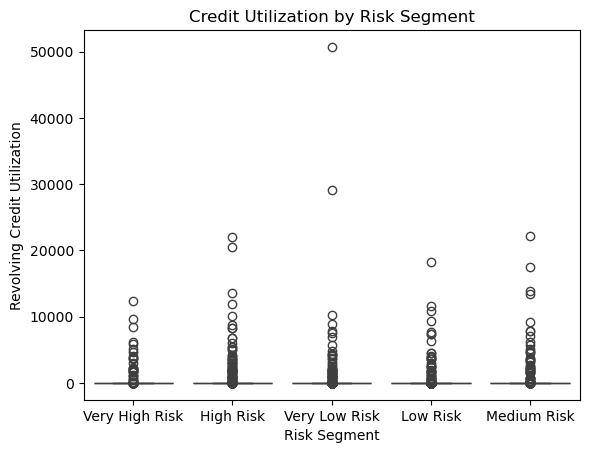

In [49]:
sns.boxplot(x = "risk_segment", y = "revolving_utilization", data = df)

plt.title("Credit Utilization by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Revolving Credit Utilization")

plt.show()

### Income Distribution

The original income distribution was highly right-skewed due to a small number of extremely high-income borrowers.

To improve interpretability, a logarithmic transformation was applied to the monthly income variable. The resulting distribution revealed a more normal pattern, with most borrowers clustered around moderate income levels.

Log transformations are commonly used in financial modelling to stabilize variance and reduce the influence of extreme outliers

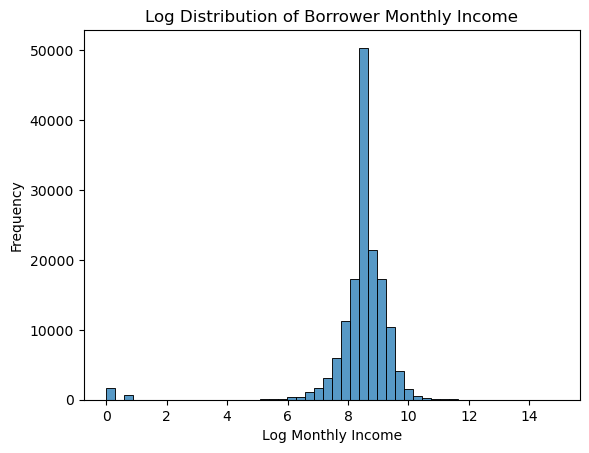

In [50]:
sns.histplot(np.log1p(df["monthly_income"]), bins = 50)

plt.title("Log Distribution of Borrower Monthly Income")
plt.xlabel("Log Monthly Income")
plt.ylabel("Frequency")

plt.show()

The distribution of borrower income is highly right-skewed due to the presence of extreme high-income values.

To better visualize the distribution, a logarithmic transformation was applied to the income variable.

### Age vs Risk Segment

The age distribution varies across risk segments. Borrowers classified as Very Low Risk tend to be older on average, while Very High Risk borrowers appear younger.

Older borrowers may have more established credit histories, greater financial stability, and more consistent repayment behavior, which can contribute to to lower credit risk.

Conversely, younger borrowers may have shorter credit histories and less financial experience, potentially increasing uncertainty in their repayment behavior.

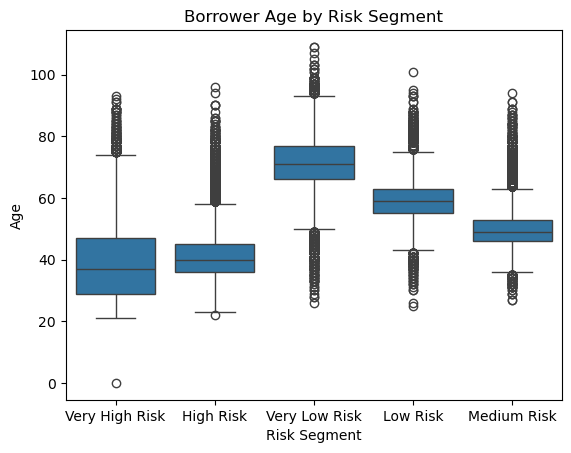

In [51]:
sns.boxplot(x = "risk_segment", y = "age", data = df)

plt.title("Borrower Age by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Age")

plt.show()

### Correlation Heatmap

The correlation matrix highlights relationships between financial variables in the dataset.

A strong positive relationship can be observed between probability of default (PD) and total late payments, indicicating that borrowers with a history of missed payments are significantly more likely to default.

Exposure at default (EAD) also shows correlation with revolving credit utilization, suggesting that borrowers who utilize a larger share of their available credit may carry greater financial exposure.

These relationships provide useful insights into the drivers of credit risk within the borrower portfolio.

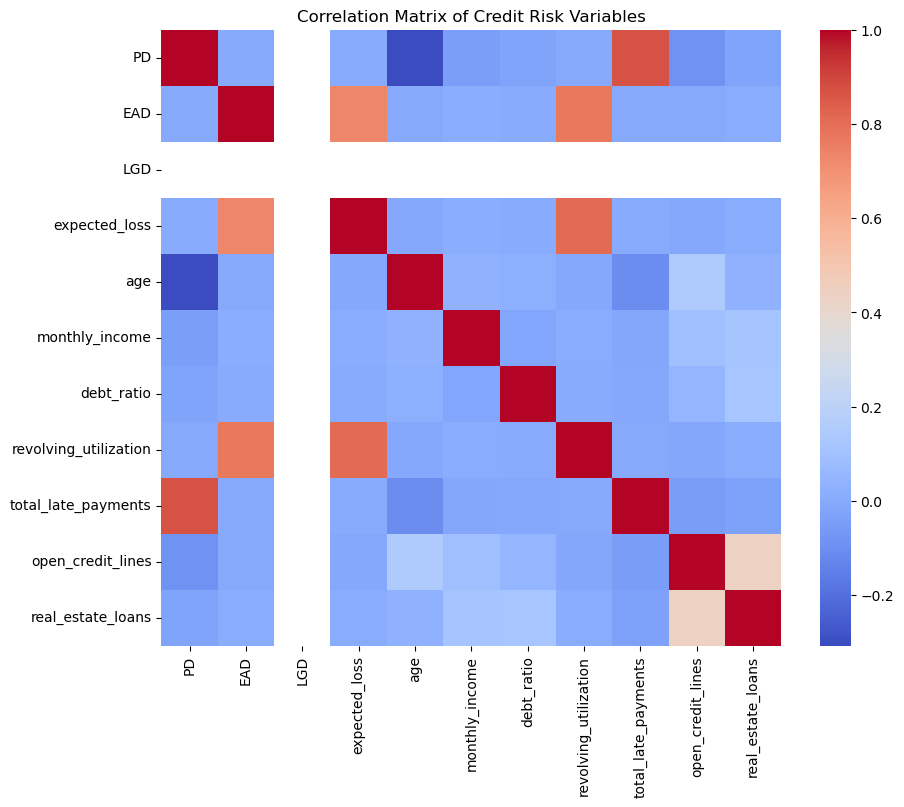

In [52]:
plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(numeric_only = True), cmap = "coolwarm")
plt.title("Correlation Matrix of Credit Risk Variables")

plt.show()

### Expected Loss Distribution 

The expected loss variable exhibits a highly right-skewed distribution, with a small number of borrowers contributing disproportionately large losses.

A logarithmic transformation was applied to improve visualization and reveal the underlying distribution. The transformed distribution shows that most borrowers generate relatively small expected losses, while a minority contribute significantly higher loss exposure,

This long-tailed pattern is typical in credit portfolios where a small number of high-risk borrowers account for a large share of potential losses.

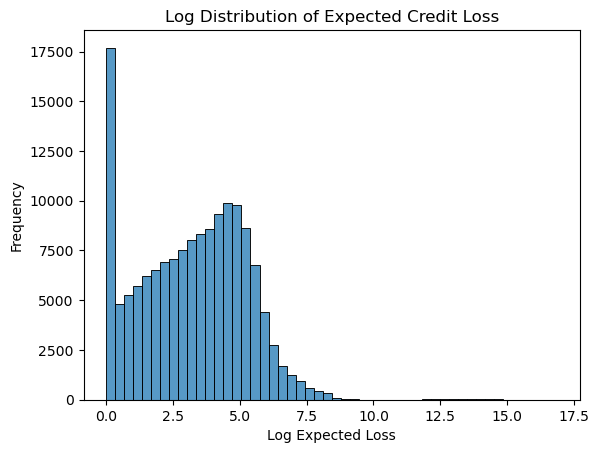

In [53]:
sns.histplot(np.log1p(df["expected_loss"]), bins = 50)
plt.title("Log Distribution of Expected Credit Loss")
plt.xlabel("Log Expected Loss")
plt.ylabel("Frequency")

plt.show()

The expected loss distribution is highly right-skewed, with a small number of borrowers contributing disproportionately large losses.

To improve visualization and interpretability, a logarithmic transformation was applied to the expected loss variable. This transformation reduces the impact of extreme values and reveals the underlying distribution exposure across borrowers.

### Expected Loss by Risk Segment

From the results we can determine that borrowers classified in higher risk categories tend to generate larger expected losses.

Very High Risk borrowers exhibit the greatest expected loss values, indicating a higher probability of default combined with greater financial exposure.

This relationship highlights the importance of risk segmentation in credit portfolio management, as identifying high-risk borrowers allowes lenders to manage potential losses.

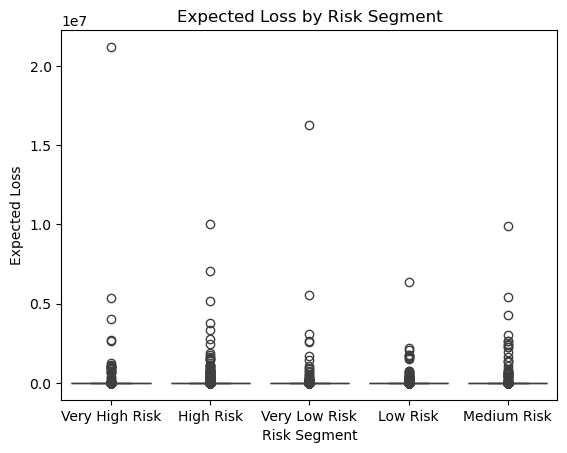

In [54]:
sns.boxplot(x = "risk_segment", y = "expected_loss", data = df)

plt.title("Expected Loss by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Expected Loss")

plt.show()

### Average Expected Loss by Risk Segment

Average expected loss increases with borrower risk level, demonstrating the financial impact of credit risk segmentation.

Borrowers in the High Risk and Very High Risk categories generate significantly larger expected losses compared to lower risk segments. This pattern illustrates how risk classification translates directly into potential financial exposure for lenders.

Understanding how expected losses vary across risk segments allows financial institutions to better allocate capital and manage portfolio risk.

In [55]:
avg_loss = df.groupby("risk_segment")["expected_loss"].mean()
avg_loss

risk_segment
High Risk         2447.565727
Low Risk          1073.732072
Medium Risk       1953.584287
Very High Risk    2113.796878
Very Low Risk     1500.416466
Name: expected_loss, dtype: float64

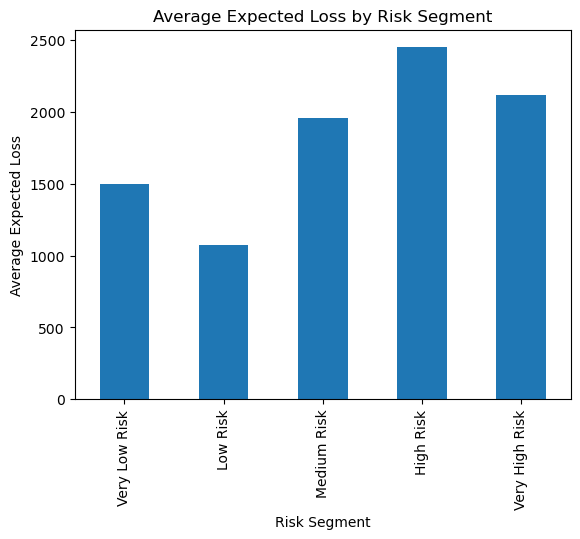

In [56]:
order = ["Very Low Risk", "Low Risk", "Medium Risk", "High Risk", "Very High Risk"]
avg_loss = df.groupby("risk_segment")["expected_loss"].mean().reindex(order)
avg_loss.plot(kind="bar")

plt.title("Average Expected Loss by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Average Expected Loss")

plt.show()

## Model Development

After exploring borrower characteristics and risk patterns in the dataset, the next step is to develop a machine learning model capable of predicting borrower risk segments.

The objective of the model is to classify borrowers into credit risk categories using financial and behavioral variables.

Predicting borrower risk allows lenders to proactively manage credit exposure and identify high-risk borrowers before potential default occurs.

In [57]:
#ML models require numerical inputs

encoder = LabelEncoder()
df["risk_segment_encoded"] = encoder.fit_transform(df["risk_segment"])

features = ["age", "monthly_income", "debt_ratio", "revolving_utilization", "total_late_payments", "open_credit_lines", "real_estate_loans"]
X = df[features]
y = df["risk_segment_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


### Model Selection

A Random Forest classifier was selected for this task due to its strong performance on structured tabular data

In [58]:
model = RandomForestClassifier(n_estimators = 120, max_depth = 8, random_state = 42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      6013
           1       0.84      0.84      0.84      5979
           2       0.82      0.82      0.82      5995
           3       0.95      0.92      0.94      5931
           4       0.94      0.91      0.93      6082

    accuracy                           0.88     30000
   macro avg       0.88      0.88      0.88     30000
weighted avg       0.88      0.88      0.88     30000



The Random Forest model achieved an overall accuracy of approximately 88% in predicting borrower risk segments.

Precision, recall, and F1-scores remain consistently high across all risk categories, indicating that the model performs reliably when classifying borrowers across different levels of credit risk.

These results suggest that the selected borrower characteristics provide strong predictive signals for identifying borrower risk.

<function matplotlib.pyplot.show(close=None, block=None)>

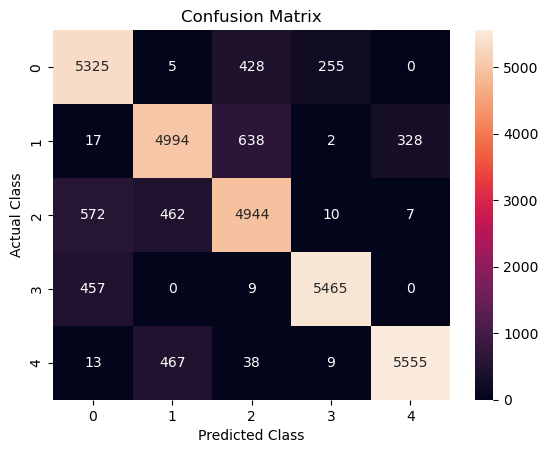

In [59]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot = True, fmt = "d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show

The confusion matrix provides a detailed view of the model's classification performance.

Most predictions fall along the diagonal of the matrix, indicating that the model correctly identifies the majority of borrower risk categories.

Misclassifications occur primarily between neighbouring risk segments, which is expected because adjacent risk categories often share similar borrower characteristics.

### Feature Importance

This analysis reveals which borrower characteristics contribute most strongly to credit risk predictions.

Age emerges as the most influential predictor, followed by total late payments and borrower income. These variables appear to play a central role in distinguishing between different borrower risk categories.

Late payment history is particularly important, reinforcing the significance of repayment behaviour in credit risk modelling.

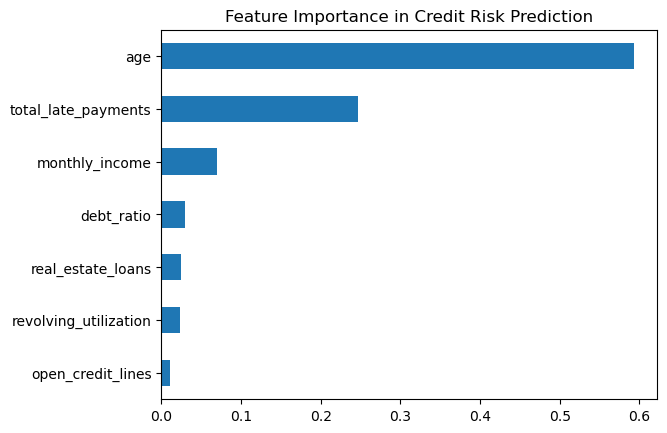

In [60]:
importance = pd.Series(model.feature_importances_, index = features)
importance.sort_values().plot(kind = "barh")

plt.title("Feature Importance in Credit Risk Prediction")
plt.show()

In [61]:
joblib.dump(model, "credit_risk_model.pkl")

['credit_risk_model.pkl']